# 10 · Simulate a campaign

**Step 0 of the workflow.** Nothing here organises anything — this is a
campaign writing files, the way a campaign does. Run it once; `11` and `12`
use what it leaves behind.

The campaign is a **Cu–Au alloy nanocatalyst library for CO₂
electroreduction**: eight alloys from pure copper to pure gold, plus one
synthesis that failed, characterised the way a real campaign would be —
fifteen techniques across four stages, by different people, on different
instruments, in different rooms.

| stage | what was done |
|---|---|
| **synthesis** | the recipe — composition, reagents, conditions; one run aborted |
| **characterization** | UV-Vis (in-situ growth), EDS, XPS, Raman, IR, SAXS, WAXS, 2D SAXS, XAS, XPCS — and TEM, SEM, DLS, tomography |
| **testing** | CO₂ reduction, hydrogen and oxygen evolution, product Faradaic efficiencies |
| **computation** | DFT: density of states, CO and H adsorption energies |

**Everything follows from one hidden number per sample — the gold atomic
fraction *x*.** Fifteen techniques see fifteen different shadows of it, so
measurements that never met can be checked against each other, and — because
this is simulated — against the truth.

```
~/Repos/OrgDemo/CuAu/
├── Campaign/                what the instruments and the people wrote
│   ├── MetaData/            four *_dict.py, one per stage, keyed by sample id
│   ├── RawSpectra/          UV-Vis growth series — every sample in one folder
│   ├── Spectroscopy/  Scattering/  Dynamics/  Electrochemistry/  Computation/
│   └── TEMData/  SEMData/  DLSData/  TomoData/     ← nobody wrote these down
├── truth.csv                the answer key (this notebook)
├── cuau.json                the organizer (notebook 11)
└── results/                 stored fits (notebook 12)
```

The generator is `NanoOrganizer.demo.build_showcase_project`. The web app's
**🎓 Demo** page and `python -m NanoOrganizer.demo --campaign` call the same
function, so all three routes write identical files.

In [1]:
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from NanoOrganizer import structure
from NanoOrganizer.demo import build_showcase_project, demo_root, showcase_truth
from NanoOrganizer.demo import materials as mat
from NanoOrganizer.viz import plots

ROOT = demo_root("CuAu")          # ~/Repos/OrgDemo/CuAu, or under $NANOORGANIZER_DEMO_ROOT
CAMPAIGN = ROOT / "Campaign"

# The hidden number, one per sample. CuAu09 is the failed run and has none.
fractions = {mat.sample_id(i): x for i, x in enumerate(mat.DEFAULT_FRACTIONS, start=1)}
fractions

{'CuAu01': 0.0,
 'CuAu02': 0.1,
 'CuAu03': 0.25,
 'CuAu04': 0.4,
 'CuAu05': 0.55,
 'CuAu06': 0.7,
 'CuAu07': 0.85,
 'CuAu08': 1.0}

## One number, fifteen shadows

The two metals are miscible at every composition, so the series is a real
material rather than a thought experiment — and the textbook consequences
arrive together. These are the generator's own functions
(`NanoOrganizer.demo.materials`), drawn before a single file exists:

* the **lattice parameter** follows Vegard's law, so a diffraction peak
  measures composition;
* the particles keep **one plasmon band** that moves from ~580 to ~520 nm —
  the evidence of an alloy; a mixture of copper and gold particles would show
  two fixed bands instead;
* **three sizes disagree for a reason**: TEM sees primary particles, DLS the
  solvated object weighted by d⁶, XPCS the loose aggregates of the ink;
* gold **segregates to the surface**, so XPS (top nanometres) reads richer in
  gold than EDS (the whole particle);
* the **d-band centre** sets how strongly CO binds, and the CO partial current
  is a **Sabatier volcano** in that binding energy — the reason anyone builds
  a composition series in the first place.

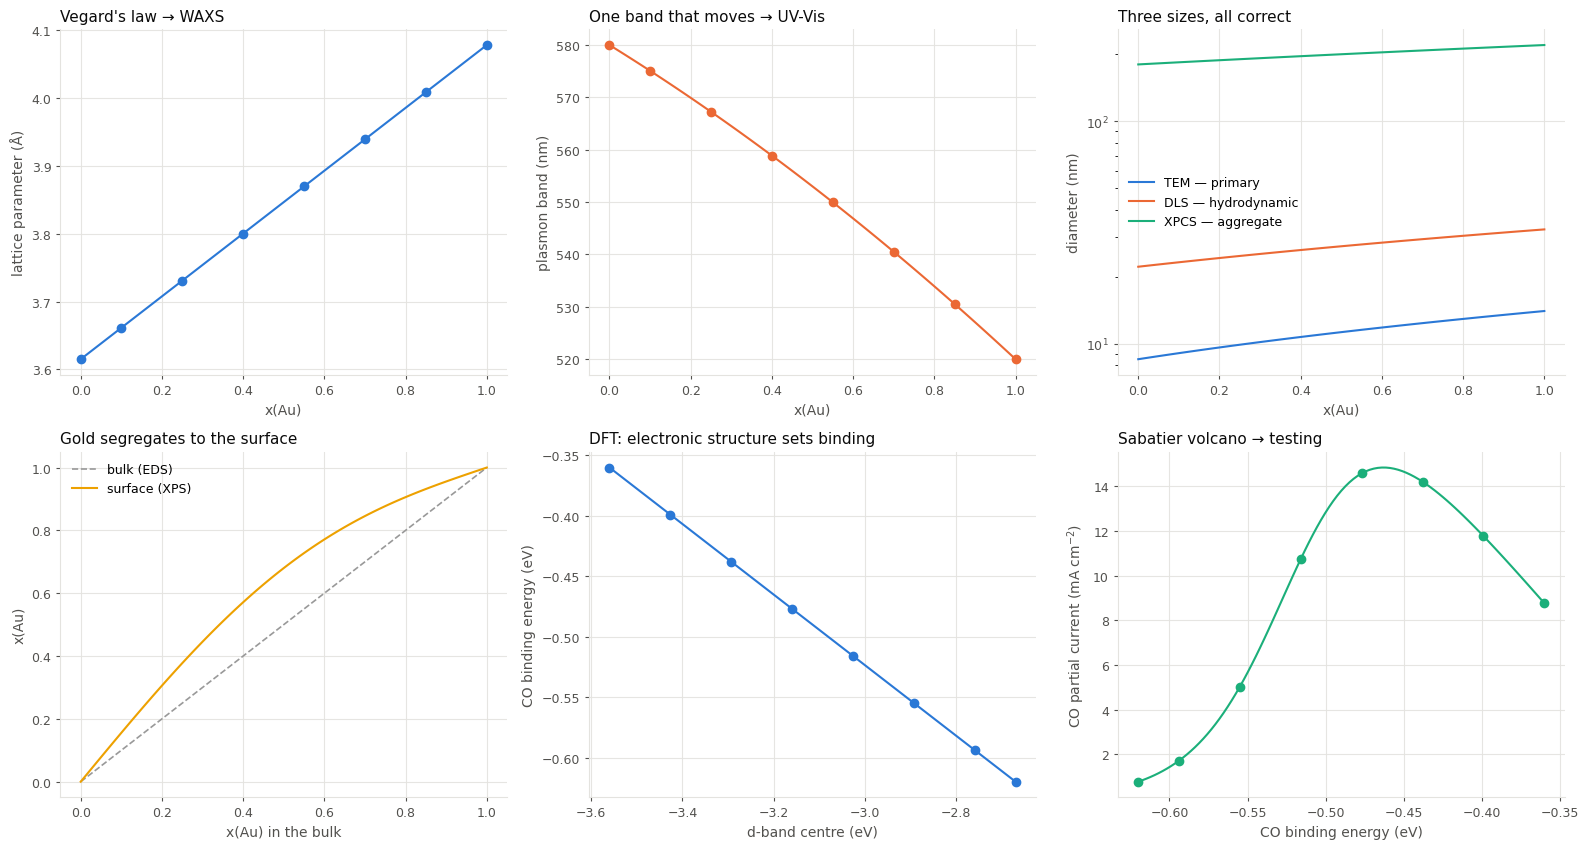

In [2]:
x = np.linspace(0.0, 1.0, 101)
xs = np.array(list(fractions.values()))
blue, orange, aqua, yellow = plots.CATEGORICAL[:4]

fig, axes = plt.subplots(2, 3, figsize=(16, 8.6))
(a, b, c), (d, e, f) = axes

a.plot(x, mat.lattice_parameter_A(x), color=blue)
a.plot(xs, mat.lattice_parameter_A(xs), "o", color=blue)
plots.style(a, "x(Au)", "lattice parameter (Å)", "Vegard's law → WAXS")

b.plot(x, mat.lspr_nm(x), color=orange)
b.plot(xs, mat.lspr_nm(xs), "o", color=orange)
plots.style(b, "x(Au)", "plasmon band (nm)", "One band that moves → UV-Vis")

for curve, colour, label in ((mat.particle_diameter_nm, blue, "TEM — primary"),
                             (mat.hydrodynamic_nm, orange, "DLS — hydrodynamic"),
                             (mat.aggregate_nm, aqua, "XPCS — aggregate")):
    c.plot(x, [curve(v) for v in x], color=colour, label=label)
c.set_yscale("log")
plots.style(c, "x(Au)", "diameter (nm)", "Three sizes, all correct")
c.legend(frameon=False, fontsize=9)

d.plot(x, x, "--", color="0.6", lw=1.2, label="bulk (EDS)")
d.plot(x, [mat.surface_au_fraction(v) for v in x], color=yellow, label="surface (XPS)")
plots.style(d, "x(Au) in the bulk", "x(Au)", "Gold segregates to the surface")
d.legend(frameon=False, fontsize=9)

e.plot(mat.d_band_centre_eV(x), mat.co_binding_eV(x), color=blue)
e.plot(mat.d_band_centre_eV(xs), mat.co_binding_eV(xs), "o", color=blue)
plots.style(e, "d-band centre (eV)", "CO binding energy (eV)",
            "DFT: electronic structure sets binding")

f.plot(mat.co_binding_eV(x), [mat.co_partial_current(v) for v in x], color=aqua)
f.plot(mat.co_binding_eV(xs), [mat.co_partial_current(v) for v in xs], "o", color=aqua)
plots.style(f, "CO binding energy (eV)", "CO partial current (mA cm$^{-2}$)",
            "Sabatier volcano → testing")
fig.tight_layout()

## Write it

One call writes the whole campaign — curves, micrographs, a tomogram, detector
images, correlation functions, electrochemistry, DFT output, and the metadata
the operators kept. Re-running overwrites it with the same numbers; it only
ever deletes a folder it made itself, so pointing it at real data cannot.

In [3]:
start = time.perf_counter()
build_showcase_project(CAMPAIGN)
print(f"wrote {CAMPAIGN} in {time.perf_counter() - start:.1f} s\n")

print(structure.tree(CAMPAIGN, depth=1))

wrote /home/yuzhang/Repos/OrgDemo/CuAu/Campaign in 0.7 s

📁 Campaign  11 folders · 1 file · .txt 1 · 1 hidden
├── 📁 Computation  8 folders
├── 📁 DLSData  8 folders
├── 📁 Dynamics  3 folders
├── 📁 Electrochemistry  8 folders
├── 📁 MetaData  4 files · .py 4
├── 📁 RawSpectra  1 folder
├── 📁 Scattering  8 folders
├── 📁 SEMData  8 folders
├── 📁 Spectroscopy  8 folders
├── 📁 TEMData  8 folders
├── 📁 TomoData  2 folders
└── 📄 README.txt  1.2 KB


## What the people wrote down

Four metadata modules, one per stage, each a dict keyed by sample id. A block
that **names files** becomes a measurement when it is ingested; everything
else is kept as a parameter. Here is one sample's characterization record —
`structure.tree` descends into a Python module the same way it descends into a
folder, without loading any data.

In [4]:
print(structure.tree(
    f"{CAMPAIGN}/MetaData/Characterization_dict.py::Characterization_dict/CuAu05",
    depth=2, limit=5))

🔑 CuAu05
├── · sample_id  str = CuAu05
├── 🔑 characterization_batch  5 keys
│   ├── · run_id  str = char_05
│   ├── · batch_tag  str = library_2
│   ├── · campaign  str = CuAu-CO2RR
│   ├── · status  str = done
│   └── · started_at  str = 2026-04-08T11:00:00
├── 🔑 UVVis  7 keys
│   ├── · modality  str = uvvis
│   ├── · instrument  str = DemoSpec HR4000
│   ├── · note  str = in-situ growth series; the last frame is the product
│   ├── · n_frames  int = 14
│   ├── · path_length_mm  float = 10
│   └── … +2 more  raise the per-layer limit to see them
├── 🔑 EDS  7 keys
│   ├── · modality  str = eds
│   ├── · instrument  str = DemoSEM + 100 mm2 SDD
│   ├── · beam_energy_keV  float = 20
│   ├── · quantification  str = Cliff-Lorimer
│   ├── · k_factor_Au_La_over_Cu_Ka  float = 0.85
│   └── … +2 more  raise the per-layer limit to see them
├── 🔑 XPS_Cu2p  7 keys
│   ├── · modality  str = xps
│   ├── · instrument  str = DemoXPS
│   ├── · source  str = Al Ka 1486.6 eV
│   ├── · pass_energy_eV  flo

## What nobody wrote down

Four techniques arrived as folders dropped on a share — a folder per sample,
and no record anywhere saying what they are or which sample they belong to
beyond the folder name. That is the normal state of affairs, and the reason
`11` links them by hand.

In [5]:
for folder in ("TEMData", "SEMData", "DLSData", "TomoData"):
    per_sample = sorted(p.name for p in (CAMPAIGN / folder).iterdir())
    print(f"{folder:9s} {len(per_sample)} samples: {', '.join(per_sample)}")

print("\nTEMData/CuAu05:", sorted(p.name for p in (CAMPAIGN / "TEMData" / "CuAu05").iterdir()))

TEMData   8 samples: CuAu01, CuAu02, CuAu03, CuAu04, CuAu05, CuAu06, CuAu07, CuAu08
SEMData   8 samples: CuAu01, CuAu02, CuAu03, CuAu04, CuAu05, CuAu06, CuAu07, CuAu08
DLSData   8 samples: CuAu01, CuAu02, CuAu03, CuAu04, CuAu05, CuAu06, CuAu07, CuAu08
TomoData  2 samples: CuAu01, CuAu06

TEMData/CuAu05: ['01.tif', '02.tif', '03.tif', 'note.txt']


## A sparse matrix, and a failure

Beamtime and microscope time are finite, so the expensive techniques are on a
few samples, not all of them — XAS needs copper to absorb at, so the pure-gold
sample is not on its list. And one synthesis aborted: `CuAu09` has a recipe
and no data at all. Both are kept, because a table that quietly drops them
biases every comparison made from it.

In [6]:
coverage = pd.DataFrame({
    technique: {mat.sample_id(i): ("✓" if mat.measured(technique, i) else "")
                for i in range(1, len(fractions) + 1)}
    for technique in mat.SPARSE_COVERAGE})
print(coverage.to_string())

print()
print(structure.tree(
    f"{CAMPAIGN}/MetaData/Synthesis_dict.py::Synthesis_dict/CuAu09/synthesis_batch",
    depth=1))

       xas tomo xpcs saxs2d
CuAu01   ✓    ✓    ✓      ✓
CuAu02                     
CuAu03   ✓                 
CuAu04             ✓      ✓
CuAu05   ✓                 
CuAu06        ✓            
CuAu07   ✓                 
CuAu08             ✓      ✓

🔑 synthesis_batch
├── · run_id  str = cuau_run_09
├── · batch_tag  str = library_3
├── · campaign  str = CuAu-CO2RR
├── · status  str = error
├── · aborted  bool = True
├── · started_at  str = 2026-04-11T09:30:00
├── · run_time_s  float = 420
└── · error  str = heater interlock tripped at t = 420 s; batch discarded


## The answer key

Kept **beside** the campaign rather than inside it, so `12` can check what the
pipeline recovers against what the generator actually used — the one thing
real data never lets you do.

In [7]:
truth = showcase_truth()
truth.to_csv(ROOT / "truth.csv", index=False)

truth[["sample_id", "x_Au", "true_lattice_A", "true_lspr_nm", "true_diameter_nm",
       "true_surface_x_Au", "true_co_binding_eV", "true_j_CO_mA_cm2"]].round(3)

,sample_id,x_Au,true_lattice_A,true_lspr_nm,true_diameter_nm,true_surface_x_Au,true_co_binding_eV,true_j_CO_mA_cm2
0,CuAu01,0.00,3.615,580.00,8.500,0.000,-0.620,0.768
1,CuAu02,0.10,3.661,575.08,9.050,0.156,-0.594,1.707
2,CuAu03,0.25,3.731,567.25,9.875,0.377,-0.555,5.018
3,CuAu04,0.40,3.800,558.88,10.700,0.571,-0.516,10.736
4,CuAu05,0.55,3.870,549.97,11.525,0.728,-0.477,14.576
5,CuAu06,0.70,3.939,540.52,12.350,0.846,-0.438,14.207
6,CuAu07,0.85,4.009,530.53,13.175,0.932,-0.399,11.771
7,CuAu08,1.00,4.078,520.00,14.000,1.000,-0.360,8.763


---

The data is on disk and nothing knows about it yet. **Next:
`11_build_organizer`.**